NEU Steel Surface Defect Dataset — 1,800 grayscale images across 6 defect types on hot-rolled steel: crazing, inclusion, patches, pitted surface, rolled-in scale, scratches. Comes pre-split, 240 training and 60 validation images per class.

This notebook goes from a simple logistic regression baseline, moving to ResNet18 transfer learning, then adding Grad-CAM explainability, confidence-based rejection, and an LLM layer that turns the classification into a plain-English engineering explanation. The goal wasn't just classifying images well — it was building something that could plausibly sit in a real quality control workflow.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


import os

#paths to train and validation image folders
train_path = '/content/drive/MyDrive/ NEU-DET /NEU-DET/train/images'
val_path = '/content/drive/MyDrive/ NEU-DET /NEU-DET/validation/images'

#getting class names from train folder
classes = sorted(os.listdir(train_path))

print("Dataset structure confirmed:")
print(f"Classes: {classes}")
print(f"\nTraining images per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls}: {count} images")

print(f"\nValidation images per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(val_path, cls)))
    print(f"  {cls}: {count} images")

print(f"\nTotal training images: {240 * 6}")
print(f"Total validation images: {60 * 6}")
print(f"Train/val split: 80/20")

Mounted at /content/drive
Dataset structure confirmed:
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Training images per class:
  crazing: 240 images
  inclusion: 240 images
  patches: 240 images
  pitted_surface: 240 images
  rolled-in_scale: 240 images
  scratches: 240 images

Validation images per class:
  crazing: 60 images
  inclusion: 60 images
  patches: 60 images
  pitted_surface: 60 images
  rolled-in_scale: 60 images
  scratches: 60 images

Total training images: 1440
Total validation images: 360
Train/val split: 80/20


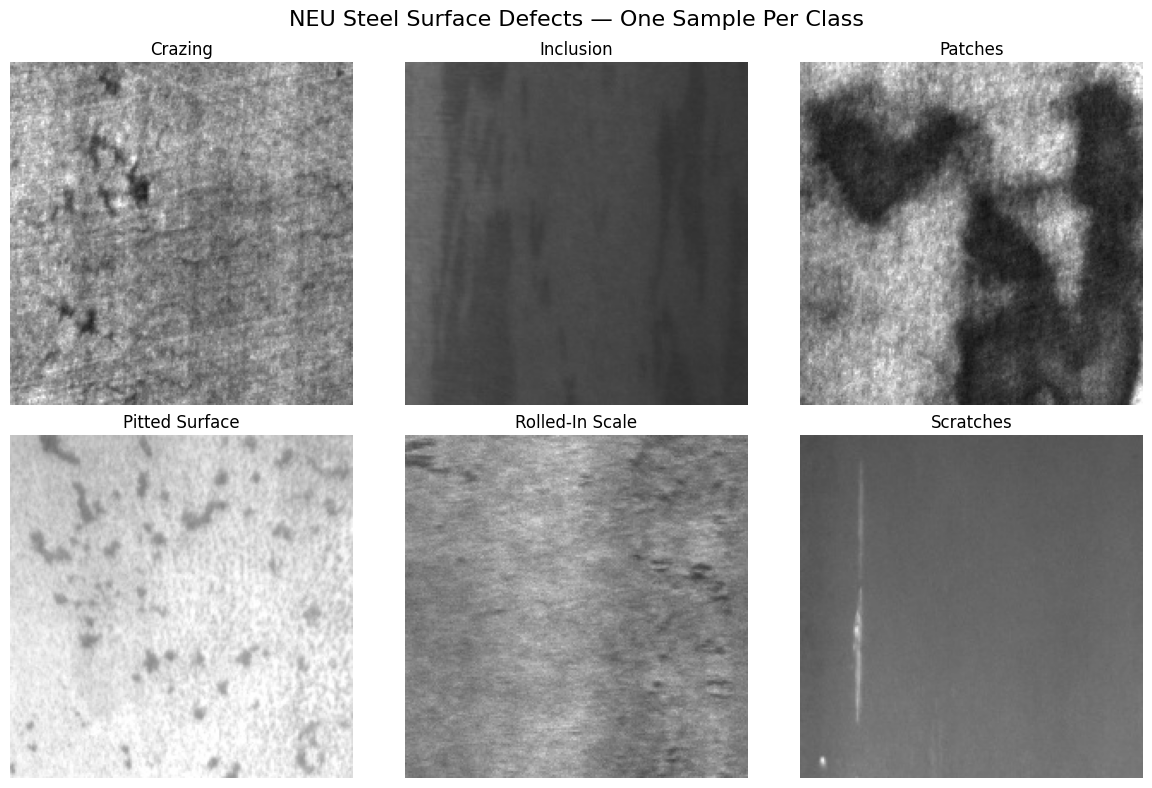

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#2 rows by 3 columns grid, one slot per defect class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('NEU Steel Surface Defects — One Sample Per Class', fontsize=16)

#loop through each defect class
for idx, cls in enumerate(classes):
    #path to this class folder
    cls_path = os.path.join(train_path, cls)

    #grabs first image filename from each class folder
    img_file = os.listdir(cls_path)[0]

    #full path to that image file
    img_path = os.path.join(cls_path, img_file)

    #load the image from file
    img = mpimg.imread(img_path)

    #idx 0,1,2 go in row 0 — idx 3,4,5 go in row 1
    #// gives the row, % gives the column
    row = idx // 3
    col = idx % 3

    #display in grayscale, steel images are black and white
    #without this matplotlib shows grayscale images in weird false colors instead of black and white
    axes[row][col].imshow(img, cmap='gray')

    #use class name as title, replaced underscore with space for readability
    axes[row][col].set_title(cls.replace('_', ' ').title(), fontsize=12)
    axes[row][col].axis('off')

plt.tight_layout()
#save for readme
plt.savefig('defect_samples.png', dpi=150)
plt.show()

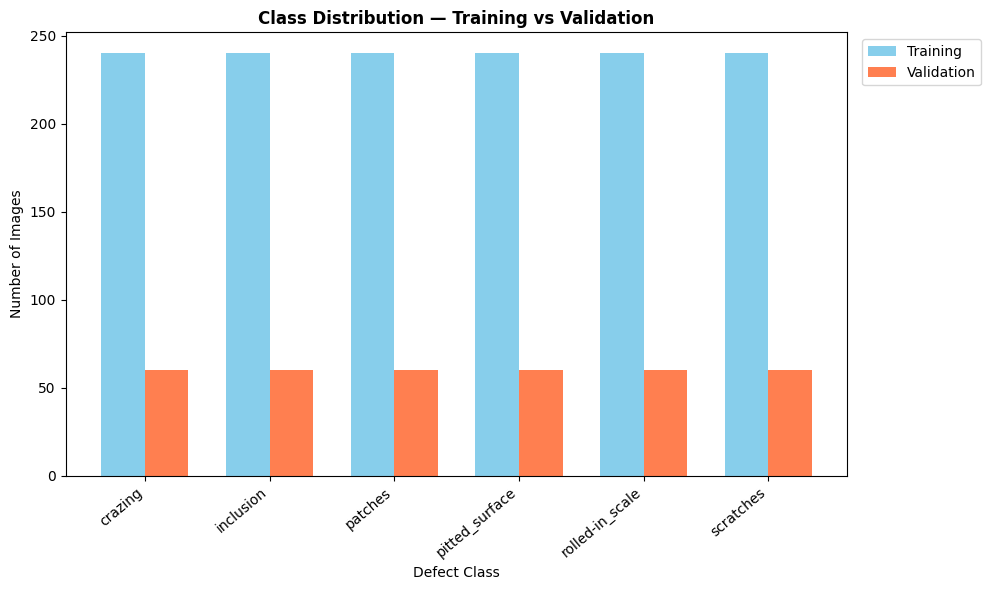

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#prepare data
categories = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Training = [240, 240, 240, 240, 240, 240]
Validation = [60, 60, 60, 60, 60, 60]

#set bar positions and width
x = np.arange(len(categories))
width = 0.35

#create figure
fig, ax = plt.subplots(figsize=(10, 6))

#plot two sets of bars side by side
rects1 = ax.bar(x - width/2, Training, width, label='Training', color='skyblue')
rects2 = ax.bar(x + width/2, Validation, width, label='Validation', color='coral')


ax.set_title('Class Distribution — Training vs Validation', fontweight='bold')
ax.set_xlabel('Defect Class')
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=40, ha='right')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1))

plt.tight_layout()
#save for the readme
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#training transforms, includes augmentation to reduce overfitting
#augmentation creates variations of each image so model sees different versions each epoch
transform_train = transforms.Compose([
    #resize from 200x200 to 224x224 as resnet18 expects exactly 224x224
    transforms.Resize((224, 224)),
    #convert grayscale to 3 channels as resnet18 expects RGB not grayscale
    transforms.Grayscale(num_output_channels=3),
    #randomly flip horizontally, a flipped defect is still the same defect
    #doubles the variety of images the model sees
    transforms.RandomHorizontalFlip(),
    #randomly rotate up to 10 degrees, adds variation without distorting defects
    transforms.RandomRotation(10),
    #from PIL image to pytorch tensor so the model can process it
    transforms.ToTensor(),
    #resnet18 was trained on ImageNet with these exact normalization values
    #images normalized the same way or transfer learning breaks
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#validation transforms — no augmentation, just resize and normalize
#consistent evaluation needed, no random changes during testing
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#load training dataset using ImageFolder
#ImageFolder automatically assigns class labels based on subfolder names(carzing folder = class 0, for instance)
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform_train
)

#load validation dataset
val_dataset = datasets.ImageFolder(
    root=val_path,
    transform=transform_val
)

#created dataloaders to feeds images in batches of 32 during training, cant feed all 1440 at once
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

#not shuffling validation as order doesnt affect accuracy measurement(unlike I did with train data)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2 #got 2 cpu CPU cores load images in parallel while GPU trains
)

#to confirm everything loaded correctly
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class to index mapping: {train_dataset.class_to_idx}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training images: 1440
Validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Training batches: 45
Validation batches: 12


Before touching ResNet18, a logistic regression baseline was trained first. Without a baseline, a high accuracy number doesn't actually mean much as there's nothing to compare it against. Logistic regression flattens every image into raw pixel values, so it has zero understanding of spatial structure — no edges, no textures, nothing. Whatever it scores becomes the floor the real model needs to clearly beat.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
from PIL import Image

print("Extracting features for baseline classifier...")

def extract_features(data_path, classes, target_size=(64, 64)):
    features = []
    labels = []
    #gives both the class name (cls) and its position number (label_idx) at the same time
    for label_idx, cls in enumerate(classes):
        cls_path = os.path.join(data_path, cls)

        #goes through every single image file inside the current class folder one by one, building the full path to each image file
        for img_file in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_file)

            #open image, resize to 64x64, convert to grayscale(defects are about texture not color)
            img = Image.open(img_path).convert('L')
            #resize to 64x64 — small enough to train fast, big enough to capture patterns
            img = img.resize(target_size)

            #flatten to 1D vector — 64x64 = 4096 numbers per image
            img_array = np.array(img).flatten()

            #normalize pixel values to 0-1(keeps the math stable during training)
            img_array = img_array / 255.0
            features.append(img_array)
            labels.append(label_idx)
    #converts the Python lists into numpy arrays, Scikit-learn's LogisticRegression expects numpy arrays not Python lists
    return np.array(features), np.array(labels)

#extract features from training and validation sets
print("Extracting training features...")
X_train, y_train = extract_features(train_path, classes)

print("Extracting validation features...")
X_val, y_val = extract_features(val_path, classes)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

#train logistic regression
print("\nTraining logistic regression baseline...")
lr_model = LogisticRegression(
    max_iter=1000, #give it enough iterations to find good weights
    random_state=42, #same result every time I run it
    C=1.0 #standard regularization to prevent overfitting
)
lr_model.fit(X_train, y_train)#finds the best mathematical weights to separate the 6 classes based on raw pixel values

#evaluate on validation set
y_pred = lr_model.predict(X_val)
baseline_accuracy = accuracy_score(y_val, y_pred) * 100

print(f"\nBaseline Logistic Regression Accuracy: {baseline_accuracy:.1f}%")
print(f"This will be compared against ResNet18 transfer learning")

Extracting features for baseline classifier...
Extracting training features...
Extracting validation features...

Training features shape: (1440, 4096)
Validation features shape: (360, 4096)

Training logistic regression baseline...

Baseline Logistic Regression Accuracy: 41.4%
This will be compared against ResNet18 transfer learning


ResNet18 was pretrained on 1.2 million ImageNet images, so it already knows how to detect general visual patterns like edges, textures, shapes, before ever seeing a single steel image. All the original convolutional layers stay frozen, only the final layer gets replaced and trained. With just 1,440 training images there's no realistic way to train a CNN from scratch and get anything decent, transfer learning is what makes this actually work on a dataset this small.

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

#load pretrained ResNet18, already knows how to detect edges, textures and shapes
model = models.resnet18(pretrained=True)

#freeze all layers, not going to change the weights that were learned from ImageNet
for param in model.parameters():
    param.requires_grad = False

#replace the final layer — original outputs 1000 ImageNet classes
#new layer outputs 6 steel defect classes
#this new layer starts with random weights — it will be trained on my data
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 6)
)

#move model to GPU as its much faster than cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

#only train the parameters in the final layer, all other layers are frozen
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

#cross entropy loss, measures how wrong predictions are
criterion = nn.CrossEntropyLoss()

#reduce learning rate every 5 epochs, helps model converge precisely later
#big steps early to learn fast, small steps later to fine-tune precisely
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Model ready on: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready on: cuda
Trainable parameters: 3,078
Total parameters: 11,179,590


In [ ]:
#lists to track progress
train_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
best_epoch = 0

print("Starting ResNet18 training...")
print("-" * 60)

for epoch in range(15):

    #training mode turns dropout on
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        #send batch to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        #clear gradients from previous batch to not pile up
        optimizer.zero_grad()

        #run images through model
        outputs = model(inputs)

        #how wrong were the predictions
        loss = criterion(outputs, labels)

        #backpropagation, calculate gradients to figure out what to fix
        loss.backward()

        #update weights
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)

    #evaluation mode turns dropout off for consistent results
    model.eval()
    correct = 0
    total = 0

    #no need to track gradients when just checking performance
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total

    #save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth')

    #reduce learning rate on schedule(after every 5 epochs)
    scheduler.step()

    #store results for charts later
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/15 | "
          f"Loss: {avg_loss:.3f} | "
          f"Train: {train_acc:.1f}% | "
          f"Val: {val_acc:.1f}%"
          + (" ← best" if val_acc == best_val_acc else ""))

print("-" * 60)
print(f"Best validation accuracy: {best_val_acc:.1f}% at epoch {best_epoch}")

Starting ResNet18 training...
------------------------------------------------------------
Epoch  1/15 | Loss: 1.170 | Train: 60.1% | Val: 74.4% ← best
Epoch  2/15 | Loss: 0.489 | Train: 90.4% | Val: 90.6% ← best
Epoch  3/15 | Loss: 0.329 | Train: 92.8% | Val: 92.8% ← best
Epoch  4/15 | Loss: 0.248 | Train: 94.7% | Val: 92.8% ← best
Epoch  5/15 | Loss: 0.225 | Train: 95.0% | Val: 92.5%
Epoch  6/15 | Loss: 0.201 | Train: 95.2% | Val: 92.8% ← best
Epoch  7/15 | Loss: 0.187 | Train: 95.2% | Val: 93.6% ← best
Epoch  8/15 | Loss: 0.174 | Train: 95.2% | Val: 94.7% ← best
Epoch  9/15 | Loss: 0.149 | Train: 96.6% | Val: 95.0% ← best
Epoch 10/15 | Loss: 0.151 | Train: 96.5% | Val: 94.7%
Epoch 11/15 | Loss: 0.147 | Train: 96.0% | Val: 92.8%
Epoch 12/15 | Loss: 0.142 | Train: 96.9% | Val: 95.6% ← best
Epoch 13/15 | Loss: 0.140 | Train: 96.4% | Val: 94.7%
Epoch 14/15 | Loss: 0.135 | Train: 96.9% | Val: 95.0%
Epoch 15/15 | Loss: 0.132 | Train: 96.4% | Val: 95.8% ← best
-----------------------------

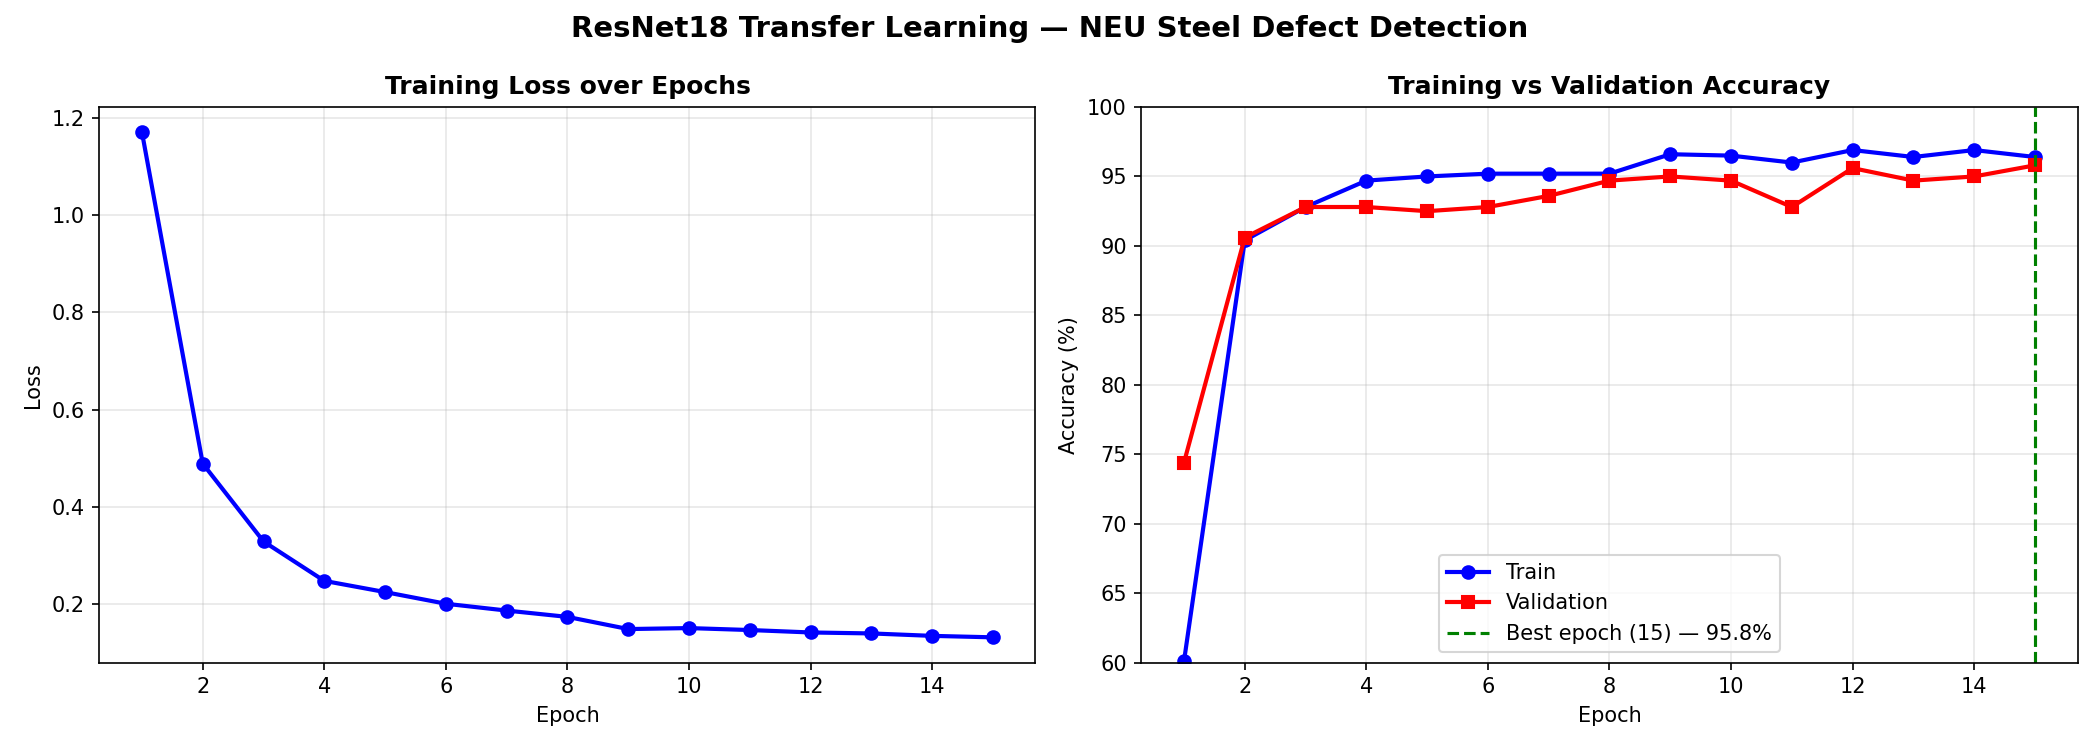

Best validation accuracy: 95.8% at epoch 15
Logistic Regression baseline: 41.4%
Improvement: 54.4 percentage points


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#two charts side by side — loss on the left, accuracy on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#left chart, training loss going down over epochs
ax1.plot(range(1, 16), train_losses,
         color='blue', marker='o', linewidth=2)
ax1.set_title('Training Loss over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

#right chart : train vs validation accuracy
#gap between lines shows overfitting
ax2.plot(range(1, 16), train_accs,
         color='blue', marker='o', label='Train', linewidth=2)
ax2.plot(range(1, 16), val_accs,
         color='red', marker='s', label='Validation', linewidth=2)

#marking where the best model was saved with a vertical line
ax2.axvline(x=best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch}) — {best_val_acc:.1f}%')

ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(60, 100)

plt.suptitle('ResNet18 Transfer Learning — NEU Steel Defect Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
#saving for readme
plt.savefig('resnet18_training.png', dpi=150)
plt.show()

print(f"Best validation accuracy: {best_val_acc:.1f}% at epoch {best_epoch}")
print(f"Logistic Regression baseline: 41.4%")
print(f"Improvement: {best_val_acc - 41.4:.1f} percentage points")

#download the best model(need for Streamlit app later)
from google.colab import files
files.download('best_model.pth')

One overall accuracy number doesn't show which specific defects the model is actually struggling with. The confusion matrix breaks that down, which classes get mixed up with which. In an industrial setting this matters more than the headline accuracy, since it shows exactly where human intervention is needed for double-checking the model.

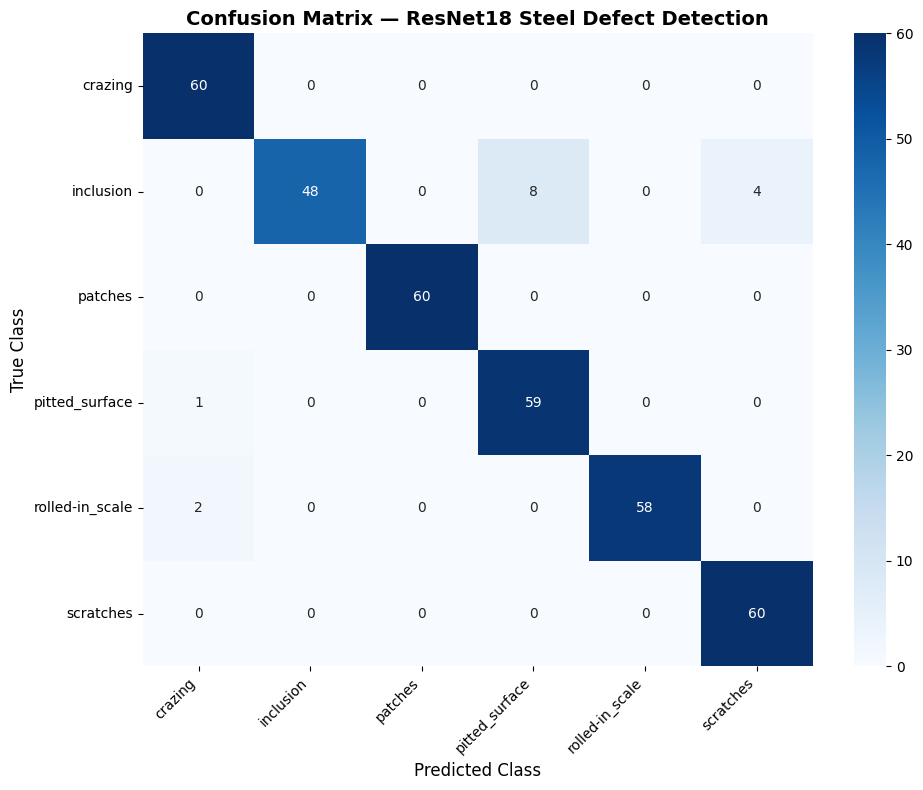


Per Class Performance:
--------------------------------------------------
crazing             : 60/60 = 100.0%
inclusion           : 48/60 = 80.0%
patches             : 60/60 = 100.0%
pitted_surface      : 59/60 = 98.3%
rolled-in_scale     : 58/60 = 96.7%
scratches           : 60/60 = 100.0%

Detailed Classification Report:
                 precision    recall  f1-score   support

        crazing       0.95      1.00      0.98        60
      inclusion       1.00      0.80      0.89        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.88      0.98      0.93        60
rolled-in_scale       1.00      0.97      0.98        60
      scratches       0.94      1.00      0.97        60

       accuracy                           0.96       360
      macro avg       0.96      0.96      0.96       360
   weighted avg       0.96      0.96      0.96       360



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

#loading the best saved model, the one that hit 95.8% at epoch 15
model.load_state_dict(torch.load('best_model.pth', map_location=device))
#evaluation mode — no dropout, consistent predictions
model.eval()

#collecting all predictions and true labels across the entire validation set
all_preds = []
all_labels = []

#no gradients needed here, just checking predictions not training
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        #taking the class with the highest score as the prediction
        _, predicted = outputs.max(1)
        #moving to cpu and converting to numpy for sklearn
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#building the 6x6 confusion matrix — rows are true classes, columns are predicted
cm = confusion_matrix(all_labels, all_preds)

#plotting as a heatmap — diagonal = correct, off-diagonal = mistakes
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,      #show numbers inside each cell
    fmt='d',         #format as integers not decimals
    cmap='Blues',    #darker blue = more predictions in that cell
    xticklabels=classes,
    yticklabels=classes,
    ax=ax
)

ax.set_title('Confusion Matrix — ResNet18 Steel Defect Detection',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
#saving for the readme
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

#breaking down the 95.8% overall accuracy by individual class
#this reveals which defects are hardest to detect
print("\nPer Class Performance:")
print("-" * 50)
for i, cls in enumerate(classes):
    class_total = cm[i].sum()
    class_correct = cm[i][i]
    class_acc = 100 * class_correct / class_total
    print(f"{cls:20s}: {class_correct}/{class_total} = {class_acc:.1f}%")

#full precision recall and f1 score per class
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

A model that just outputs "crazing, 94% confidence" with nothing backing it up isn't something a quality engineer should trust blindly. Grad-CAM shows which pixels actually drove the prediction, overlaid as a heatmap. If the model is focused on the actual defect and not some random background texture, that's real evidence the prediction is trustworthy and not just a number with no explanation behind it.

In [ ]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
#show_cam_on_image — overlays the heatmap on the original image
from pytorch_grad_cam.utils.image import show_cam_on_image
#ClassifierOutputTarget — tells GradCAM which class to explain
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
#layer4 gradients were frozen during training, need to re-enable them
#grad-cam works by tracking gradients, so requires_grad must be True
for param in model.layer4.parameters():
    param.requires_grad = True

#targeting the last convolutional layer in ResNet18
# earlier layers detect simple edges, layer4 detects high-level patterns
target_layers = [model.layer4[-1]]

#creating the grad-cam object attached to the model and target layer
cam = GradCAM(model=model, target_layers=target_layers)

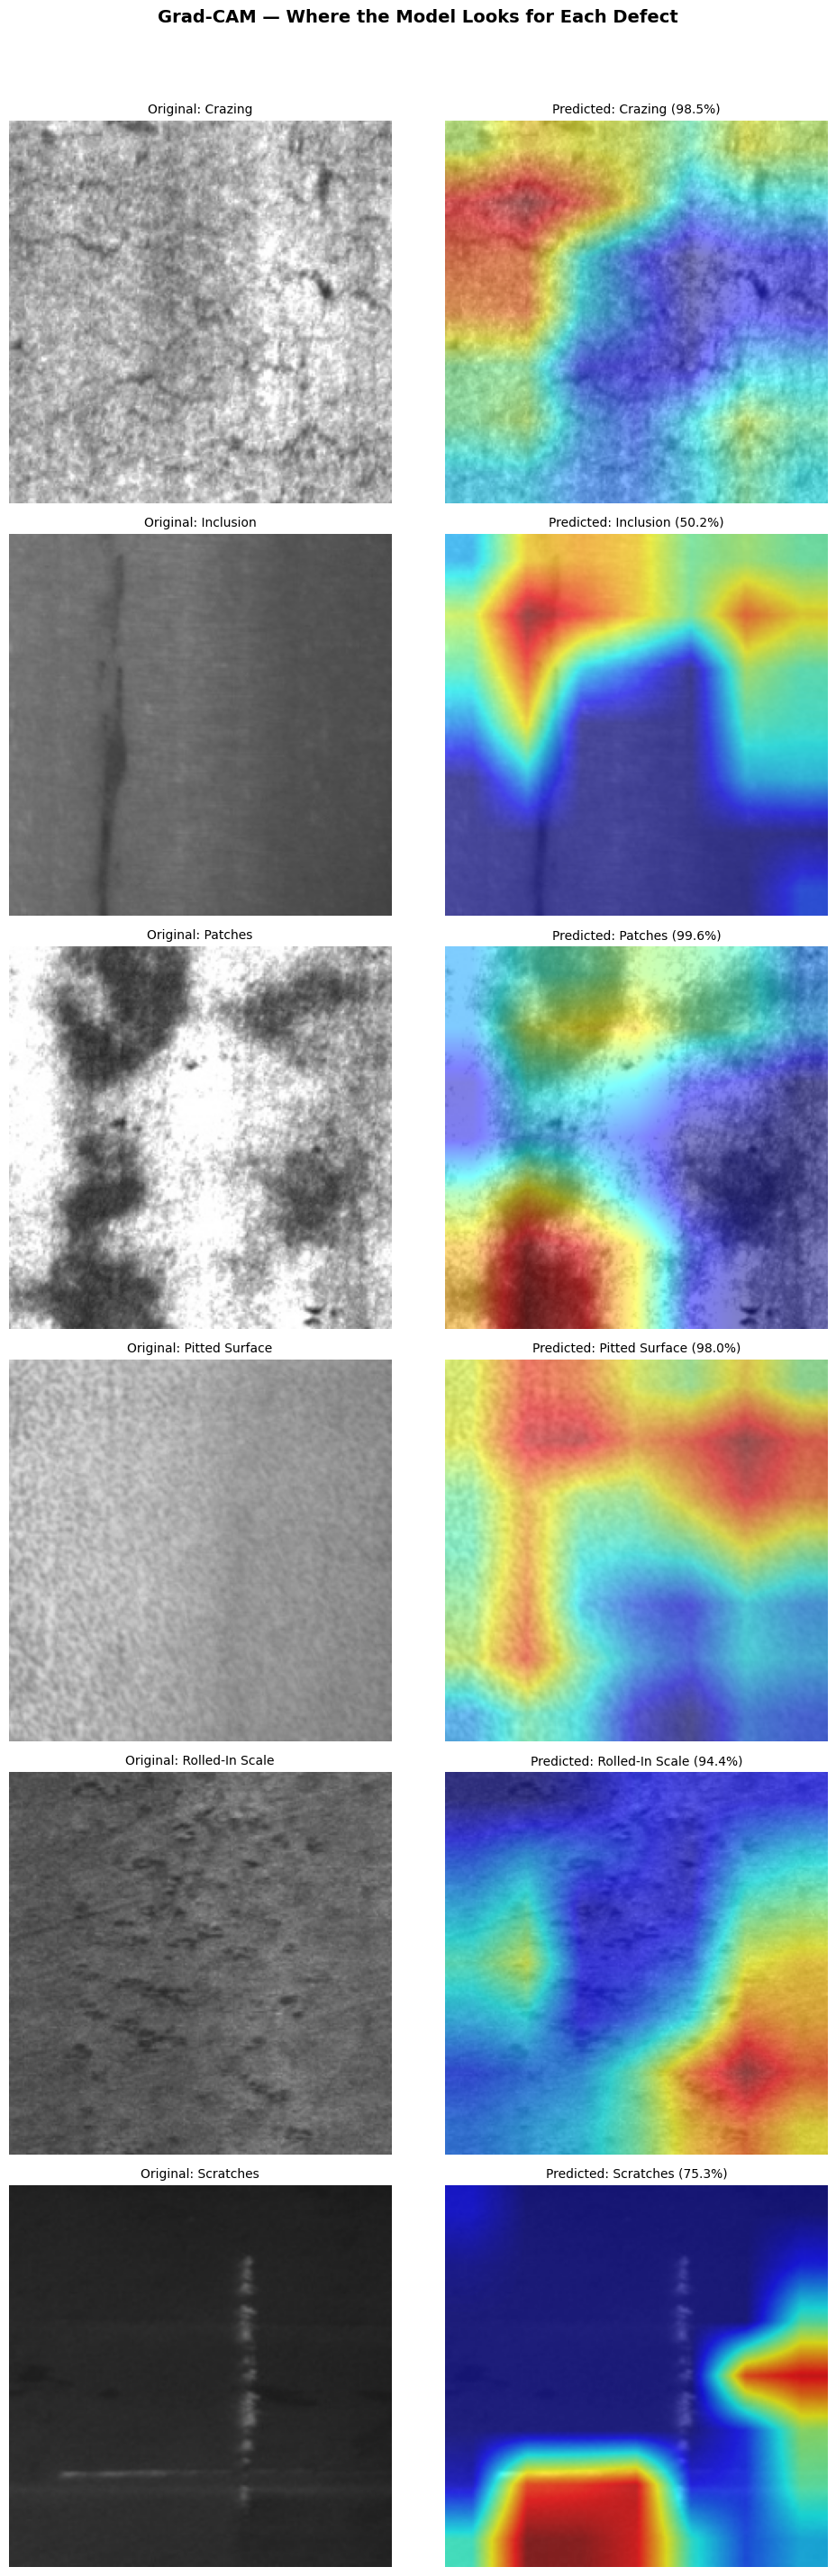

In [ ]:
#targeting the last convolutional layer, highest level spatial features live here
target_layers = [model.layer4[-1]]

#attaching grad-cam to the model and target layer
cam = GradCAM(model=model, target_layers=target_layers)

def get_gradcam(image_path, predicted_class_idx):
    #open image as RGB for display purposes
    img_pil = Image.open(image_path).convert('RGB')
    img_pil = img_pil.resize((224, 224))

    #convert to numpy array normalized 0-1, needed for overlay later
    img_array = np.array(img_pil) / 255.0

    #same transforms as training, model expects this exact format
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    #opening as grayscale, steel images are single channel
    img_original = Image.open(image_path).convert('L')
    #unsqueeze adds batch dimension, model expects [1, 3, 224, 224]
    input_tensor = transform(img_original).unsqueeze(0).to(device)

    #telling grad-cam which class to explain
    targets = [ClassifierOutputTarget(predicted_class_idx)]
    #generating the heatmap, values between 0 and 1
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    #overlaying heatmap on original image — red = high attention, blue = low
    visualization = show_cam_on_image(
        img_array.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    return visualization, grayscale_cam


#6 rows, 2 columns — original image on left, grad-cam on right
fig, axes = plt.subplots(6, 2, figsize=(10, 28))
fig.suptitle('Grad-CAM — Where the Model Looks for Each Defect',
             fontsize=14, fontweight='bold', y=1.02)

for idx, cls in enumerate(classes):
    #getting one sample image from each class in the validation set
    cls_path = os.path.join(val_path, cls)
    img_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_file)

    #preprocessing the image for prediction
    img_pil = Image.open(img_path).convert('L')
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    #getting prediction and confidence score
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)

    predicted_class = classes[predicted_idx.item()]
    conf_pct = confidence.item() * 100

    #generating grad-cam heatmap for this image
    gradcam_img, _ = get_gradcam(img_path, predicted_idx.item())

    #showing original image on the left
    original = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    axes[idx][0].imshow(original, cmap='gray')
    axes[idx][0].set_title(f'Original: {cls.replace("_", " ").title()}', fontsize=10)
    axes[idx][0].axis('off')

    #showing grad-cam heatmap on the right with prediction and confidence
    axes[idx][1].imshow(gradcam_img)
    axes[idx][1].set_title(f'Predicted: {predicted_class.replace("_", " ").title()} ({conf_pct:.1f}%)', fontsize=10)
    axes[idx][1].axis('off')

#adjusting spacing so title doesnt overlap with images
plt.subplots_adjust(top=0.95)
plt.tight_layout()
#saving for readme
plt.savefig('gradcam_visualization.png', dpi=150)
plt.show()

In [ ]:
def predict_with_confidence(image_path, threshold=0.70):
    #opening as grayscale, steel images are single channel
    img_pil = Image.open(image_path).convert('L')

    #same transforms as training (identical input format expected)
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    #unsqueeze adds batch dimension, model expects [1, 3, 224, 224]
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    #evaluation mode — no dropout, consistent predictions
    model.eval()
    #no gradients needed, just making predictions not training
    with torch.no_grad():
        output = model(input_tensor)
        #converting raw scores to probabilities, all 6 sum to 100%
        probs = torch.softmax(output, dim=1)
        #getting the highest probability and which class it belongs to
        confidence, predicted_idx = torch.max(probs, 1)

    confidence_pct = confidence.item() * 100
    predicted_class = classes[predicted_idx.item()]
    #storing all 6 class probabilities for reference
    all_probs = probs[0].tolist()

    #below threshold, not confident enough for automated decision
    #returning a warning instead of a definitive classification
    if confidence_pct < threshold * 100:
        return {
            'status': 'low_confidence',
            'message': f'Low confidence ({confidence_pct:.1f}%) — recommend manual inspection',
            'predicted_class': predicted_class,
            'confidence': confidence_pct,
            'all_probabilities': {cls: prob * 100 for cls, prob in zip(classes, all_probs)}
        }
    #above threshold, confident enough to classify automatically
    else:
        return {
            'status': 'confident',
            'predicted_class': predicted_class,
            'confidence': confidence_pct,
            'all_probabilities': {cls: prob * 100 for cls, prob in zip(classes, all_probs)}
        }

#testing on one sample image from each of the 6 classes
print("Testing confidence rejection on sample images:")
print("-" * 60)

for cls in classes:
    cls_path = os.path.join(val_path, cls)
    img_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_file)

    result = predict_with_confidence(img_path)

    #flagged — below 70% confidence
    if result['status'] == 'low_confidence':
        print(f"{cls:20s}: ⚠️  {result['message']}")
    #confident — above 70% threshold
    else:
        print(f"{cls:20s}: ✅  {result['predicted_class']} ({result['confidence']:.1f}%)")

Testing confidence rejection on sample images:
------------------------------------------------------------
crazing             : ✅  crazing (98.5%)
inclusion           : ⚠️  Low confidence (50.2%) — recommend manual inspection
patches             : ✅  patches (99.6%)
pitted_surface      : ✅  pitted_surface (98.0%)
rolled-in_scale     : ✅  rolled-in_scale (94.4%)
scratches           : ✅  scratches (75.3%)


In [ ]:
!pip install anthropic -q

Knowing the defect type and confidence score is only half useful, a quality engineer also needs to know what probably caused it and what to actually do about it. The classifier's output gets passed into a prompt that has Claude respond as an experienced steel quality engineer: what the defect is, what likely caused it during rolling, and what the production team should do next. This helps to turn a bare label into something closer to an actual inspection note.

In [ ]:
import anthropic
ANTHROPIC_API_KEY = "API_KEY_HERE"

#initializing the anthropic client with the API key
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

#quick test to verify the API connection is working
message = client.messages.create(
    model="claude-opus-4-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ]
)

print(message.content[0].text)

Hello, it's nice to meet you!


In [ ]:
def get_steel_engineer_explanation(defect_class, confidence):

    prompt = f"""You are an expert steel quality engineer at a hot-rolling steel mill with 20 years of experience in surface defect analysis and quality control.

A computer vision system has detected a {defect_class.replace('_', ' ')} defect on a steel surface with {confidence:.1f}% confidence.

Provide a concise professional engineering analysis in exactly 3 sentences:
1. What this defect is and how it appears on the steel surface
2. The most likely cause during the hot-rolling manufacturing process
3. The recommended corrective action for the production team

Be specific, technical, and practical. Write as a steel engineer would in an inspection report. Write in plain paragraph form only. No markdown, no bold, no headers, no bullet points. Just 3 plain sentences. Do not use first person. Write in third person as an official engineering report."""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=300,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    return message.content[0].text

print("Steel Engineer LLM Analysis — All 6 Defect Classes")
print("=" * 60)

#using representative confidence values to demonstrate the prompt across different scenarios
#not pulled live from this session's model run
test_cases = [
    ("crazing", 94.8),
    ("inclusion", 47.7),
    ("patches", 98.8),
    ("pitted_surface", 94.5),
    ("rolled-in_scale", 83.9),
    ("scratches", 55.1)
]

for defect_class, confidence in test_cases:
    print(f"\nDefect: {defect_class.replace('_', ' ').title()} ({confidence}% confidence)")
    print("-" * 40)
    explanation = get_steel_engineer_explanation(defect_class, confidence)
    print(explanation)
    print()

Steel Engineer LLM Analysis — All 6 Defect Classes

Defect: Crazing (94.8% confidence)
----------------------------------------
Crazing appears as a network of fine, shallow surface cracks forming an irregular pattern resembling dried mud or alligator skin, typically observable under oblique lighting conditions on the finished steel surface. This defect most commonly originates from excessive thermal stress during cooling operations, particularly when there is a significant temperature differential between the surface and core of the slab, or from inadequate descaling that allows scale to become embedded and create stress concentrations during subsequent rolling passes. The production team should verify descaler pressure and nozzle alignment, review cooling water distribution uniformity across the runout table, and consider reducing rolling speed or adjusting inter-stand cooling to minimize thermal gradients during the finishing mill sequence.


Defect: Inclusion (47.7% confidence)
---

Final result: ResNet18 hit 95.8% validation accuracy vs 41.4% for the logistic regression baseline, a 54.4 point improvement. Validation accuracy bounced around quite a bit between epochs instead of climbing smoothly, probably because the validation set is small (360 images, 60 per class), a few borderline predictions flipping correct or incorrect between epochs is enough to swing the number by a couple points. The confusion matrix showed inclusion as the hardest class, mostly confused with scratches and pitted surface, which makes sense since those defects can look visually similar. Grad-CAM showed the model was actually looking at the defect regions and not random background texture, and the confidence threshold worked as intended, flagging low-confidence predictions instead of forcing a guess.

Two things worth testing further: how the model performs on real production-line images instead of just the NEU benchmark set, since predictions on different image conditions should be checked by a human rather than trusted blindly. And whether training past 15 epochs would have pushed accuracy even higher, since validation was still climbing right up to the last epoch with no fixed stopping point ever tested.